In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
data= pd.read_csv("https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/master/winequality-red.csv",sep = ';')

In [3]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df = data.copy()

In [5]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [6]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [7]:
df.duplicated().sum()

240

In [10]:
df.shape

(1599, 12)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(1359, 12)

In [15]:
X = df.iloc[:,:-1]

In [17]:
y = df.quality

In [27]:
y.value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train, x_test, y_train, y_test= train_test_split(X, y,test_size=0.2, random_state=42)

In [21]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1087, 11), (272, 11), (1087,), (272,))

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
dt = DecisionTreeClassifier()

In [24]:
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
y_pred = dt.predict(x_test)

In [26]:
pd.DataFrame({"y_tru": y_test, "y_pred": y_pred})

,y_tru,y_pred
55,5,5
1291,6,6
1544,7,7
593,5,6
1261,4,6
...,...,...
1086,7,4
662,6,6
279,7,6
1111,7,5


In [39]:
from sklearn import tree
import matplotlib.pyplot as plt

[Text(0.47558217859892227, 0.9722222222222222, 'x[10] <= 10.25\ngini = 0.648\nsamples = 1087\nvalue = [6.0, 42.0, 457.0, 432.0, 136.0, 14.0]'),
 Text(0.31951260585065433, 0.9166666666666666, 'x[6] <= 98.5\ngini = 0.534\nsamples = 575\nvalue = [5.0, 26.0, 351.0, 173.0, 18.0, 2.0]'),
 Text(0.3975473922247883, 0.9444444444444444, 'True  '),
 Text(0.19945631254811394, 0.8611111111111112, 'x[1] <= 0.548\ngini = 0.568\nsamples = 495\nvalue = [5, 25, 277, 168, 18, 2]'),
 Text(0.07854599692070824, 0.8055555555555556, 'x[9] <= 0.585\ngini = 0.594\nsamples = 220\nvalue = [1.0, 7.0, 96.0, 101.0, 13.0, 2.0]'),
 Text(0.02771362586605081, 0.75, 'x[10] <= 9.75\ngini = 0.516\nsamples = 73\nvalue = [0, 4, 44, 25, 0, 0]'),
 Text(0.018475750577367205, 0.6944444444444444, 'x[7] <= 0.997\ngini = 0.398\nsamples = 47\nvalue = [0, 2, 35, 10, 0, 0]'),
 Text(0.012317167051578136, 0.6388888888888888, 'x[5] <= 26.5\ngini = 0.509\nsamples = 25\nvalue = [0, 1, 15, 9, 0, 0]'),
 Text(0.009237875288683603, 0.583333333

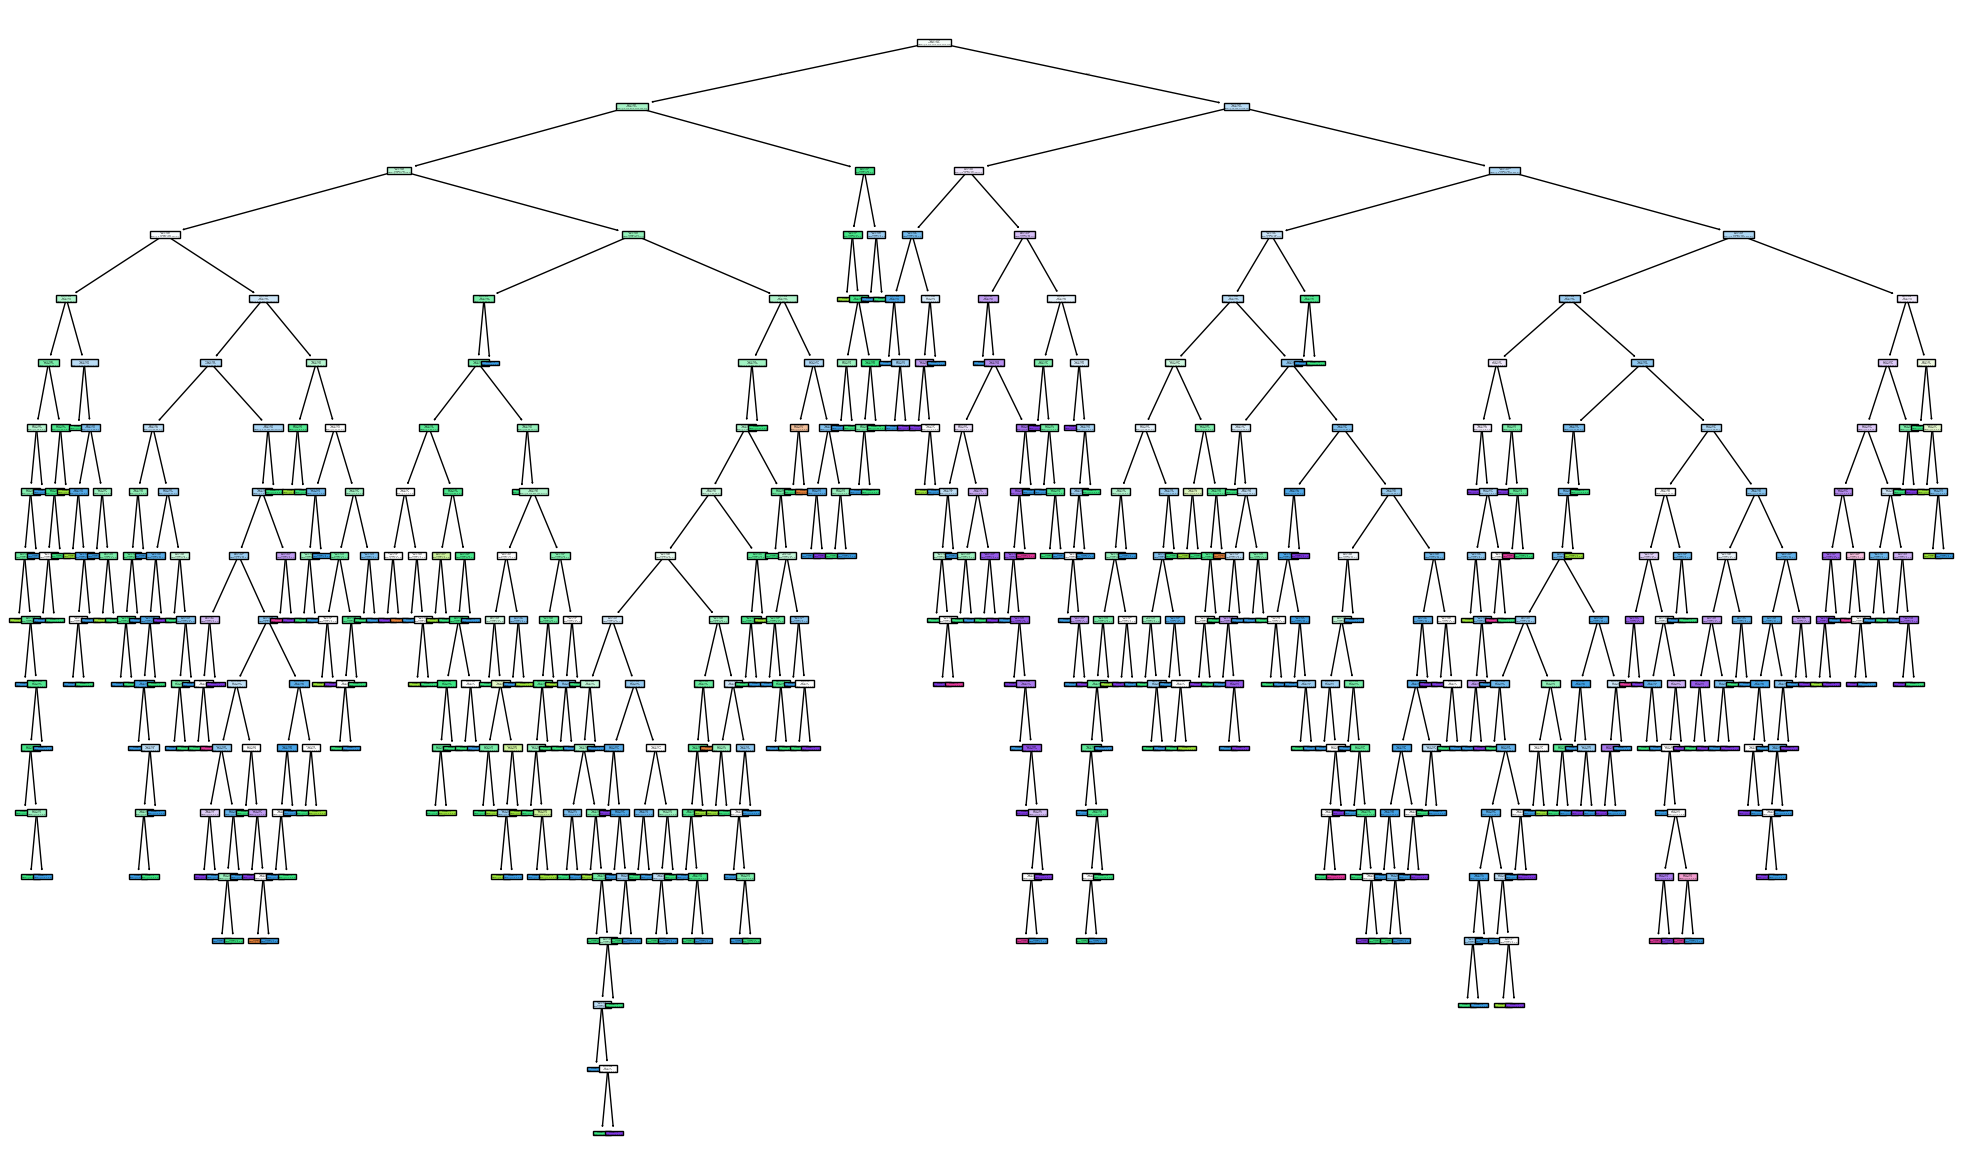

In [40]:
fig = plt.figure(figsize=(25,15))
tree.plot_tree(dt, filled = True)  

In [28]:
from sklearn.metrics import accuracy_score, classification_report

In [29]:
accuracy_score(y_test, y_pred)

0.5220588235294118

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        11
           5       0.65      0.63      0.64       120
           6       0.49      0.52      0.50       103
           7       0.40      0.39      0.39        31
           8       0.00      0.00      0.00         3

    accuracy                           0.52       272
   macro avg       0.26      0.26      0.26       272
weighted avg       0.52      0.52      0.52       272



In [32]:
from sklearn.model_selection import GridSearchCV

In [35]:
param = {"criterion" :['gini', "entropy", "log_loss"],
    "splitter":['best', "random"],
    "max_depth":[2,3,4,5],
    "min_samples_split":[3,4,5,6],
    "min_samples_leaf":[3,4,5,6],
    "max_features":[4,5,6,7,8],
    "ccp_alpha":[0.1, 0.5, 0.01, 1]}

In [37]:
gridcv = GridSearchCV(DecisionTreeClassifier(),
            param,
             cv= 5,
             scoring= "accuracy"
        )

In [38]:
gridcv.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [0.1, 0.5, ...], 'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 3, ...], 'max_features': [4, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [42]:
best_model = gridcv.best_estimator_

In [43]:
gridcv.best_params_

{'ccp_alpha': 0.01,
 'criterion': 'gini',
 'max_depth': 3,
 'max_features': 7,
 'min_samples_leaf': 6,
 'min_samples_split': 4,
 'splitter': 'best'}

[Text(0.6666666666666666, 0.875, 'x[10] <= 10.25\ngini = 0.648\nsamples = 1087\nvalue = [6.0, 42.0, 457.0, 432.0, 136.0, 14.0]'),
 Text(0.5, 0.625, 'x[6] <= 98.5\ngini = 0.534\nsamples = 575\nvalue = [5.0, 26.0, 351.0, 173.0, 18.0, 2.0]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'x[9] <= 0.575\ngini = 0.568\nsamples = 495\nvalue = [5, 25, 277, 168, 18, 2]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.487\nsamples = 199\nvalue = [2, 18, 135, 42, 2, 0]'),
 Text(0.5, 0.125, 'gini = 0.585\nsamples = 296\nvalue = [3, 7, 142, 126, 16, 2]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.14\nsamples = 80\nvalue = [0, 1, 74, 5, 0, 0]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.647\nsamples = 512\nvalue = [1, 16, 106, 259, 118, 12]'),
 Text(0.75, 0.75, '  False')]

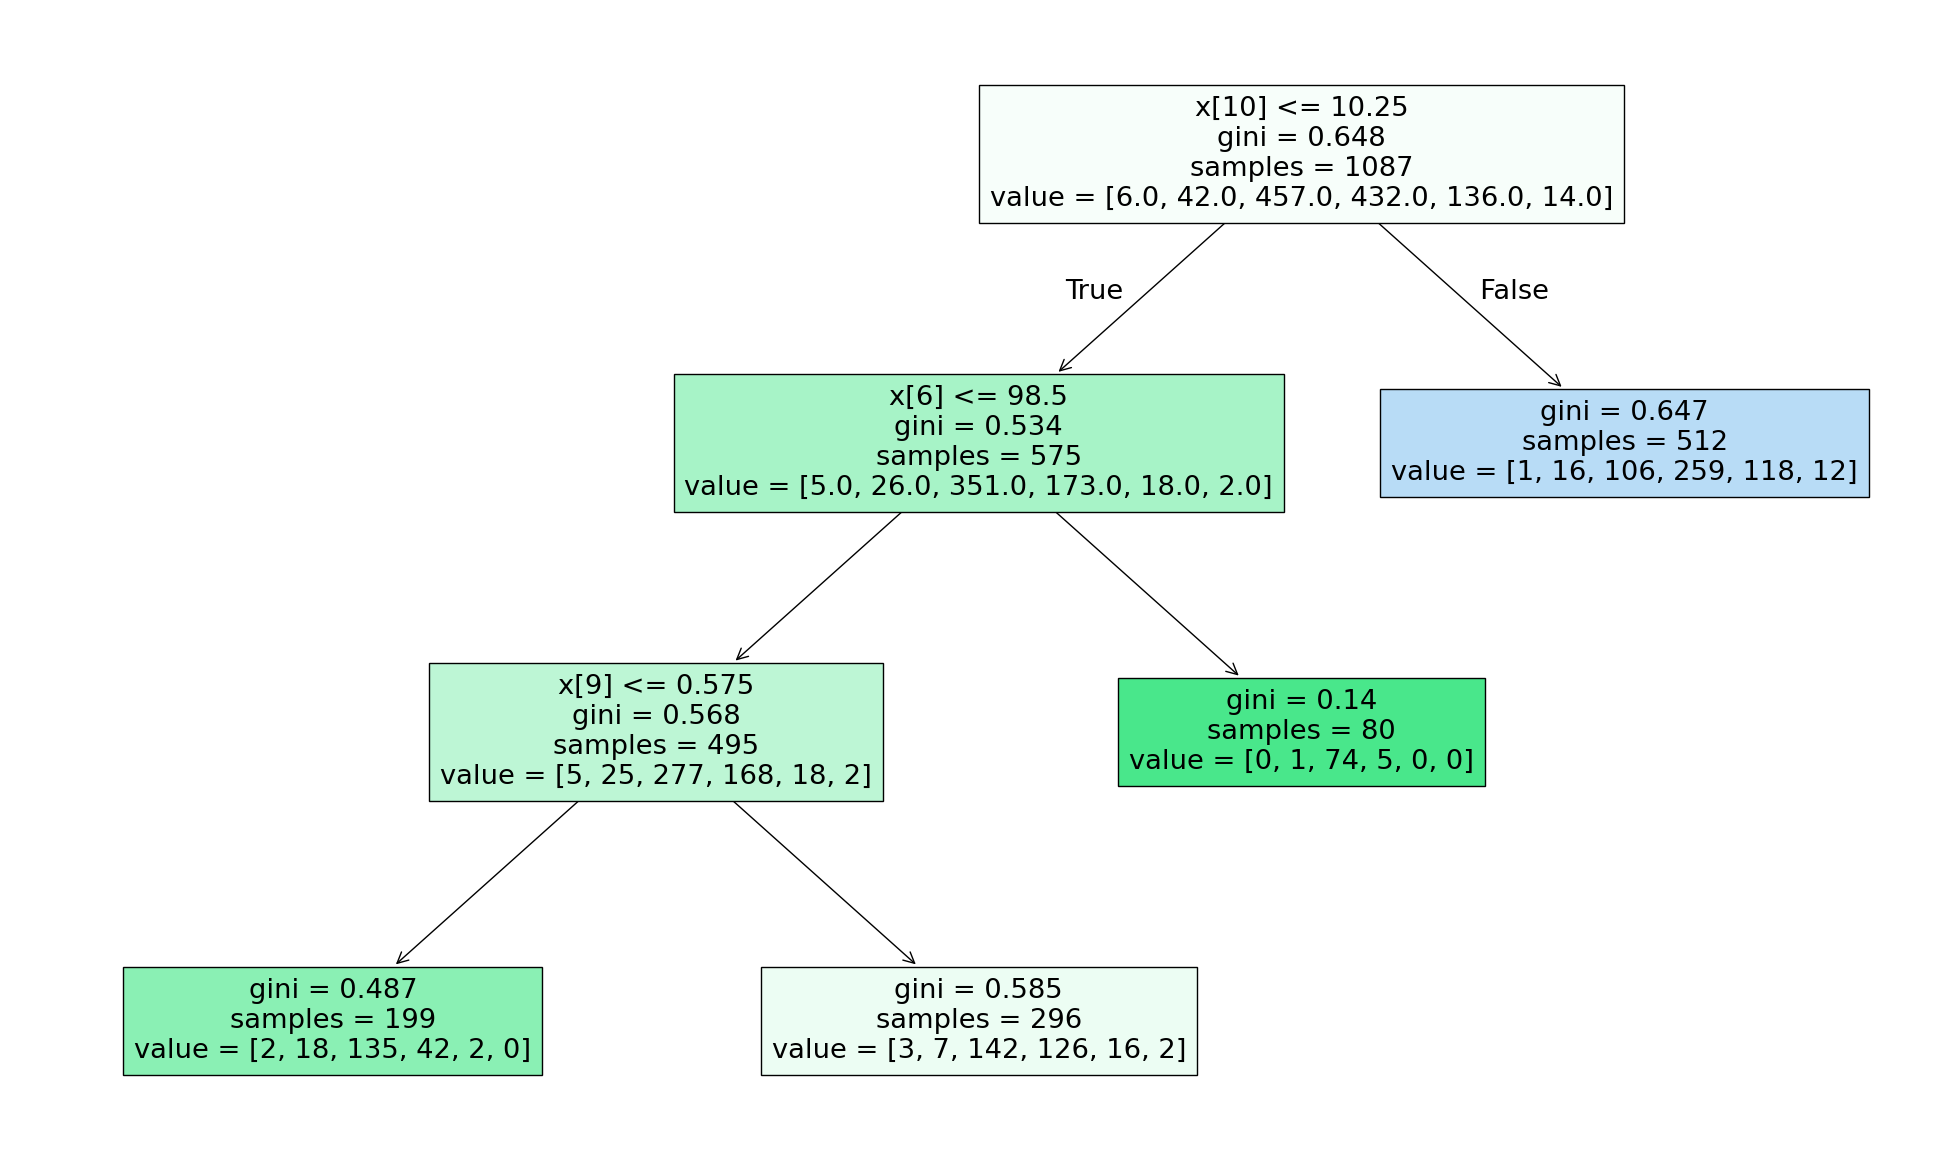

In [44]:
fig = plt.figure(figsize=(25,15))
tree.plot_tree(best_model, filled = True)   

In [45]:
y_pred_tune = best_model.predict(x_test)

In [46]:
accuracy_score(y_test,y_pred_tune)

0.5588235294117647